# KH6006 – Coursework 1 – Part 1, Question (e)
## Parallel Sum using OpenMP
**Youssef Mohamed Hanafy | ID: 202000009**

Testing with two input sizes:
- **n = 4096** — small input, shows why overhead dominates
- **n = 1,000,000** — large input, shows real speedup

## Step 1 – Write the C++ OpenMP code

In [23]:
%%writefile cw1.cpp
#include <iostream>
#include <omp.h>
#define GRAIN 128

long long parallel_sum(int* A, int n) {
    if (n <= GRAIN) {
        long long sum = 0;
        for (int i = 0; i < n; i++)
            sum += A[i];
        return sum;
    } else {
        long long x = 0, y = 0;

        #pragma omp task shared(x)
        x = parallel_sum(A, n/2);

        y = parallel_sum(A + n/2, n/2);

        #pragma omp taskwait
        return x + y;
    }
}

int main(int argc, char* argv[]) {
    int n = (argc > 1) ? atoi(argv[1]) : 4096;
    int* A = new int[n];

    for (int i = 0; i < n; i++)
        A[i] = 1;

    long long result;

    double start = omp_get_wtime();

    #pragma omp parallel
    {
        #pragma omp single
        result = parallel_sum(A, n);
    }

    double end = omp_get_wtime();

    std::cout << "n=" << n
              << " Sum=" << result
              << " Time=" << (end - start) << " seconds" << std::endl;

    delete[] A;
    return 0;
}

Overwriting cw1.cpp


## Step 2 – Compile

In [24]:
%%bash
g++ -O2 -fopenmp cw1.cpp -o cw1
echo "Compiled OK"

Compiled OK


## Step 3 – Run with n = 4096 (small input)
Expected: speedup < 1 for all thread counts — overhead dominates

In [25]:
!OMP_NUM_THREADS=1 ./cw1 4096

n=4096 Sum=4096 Time=1.9458e-05 seconds


In [26]:
!OMP_NUM_THREADS=2 ./cw1 4096

n=4096 Sum=4096 Time=0.000900845 seconds


In [27]:
!OMP_NUM_THREADS=4 ./cw1 4096

n=4096 Sum=4096 Time=0.000239987 seconds


In [28]:
!OMP_NUM_THREADS=8 ./cw1 4096

n=4096 Sum=4096 Time=0.000396489 seconds


In [29]:
!OMP_NUM_THREADS=16 ./cw1 4096

n=4096 Sum=4096 Time=0.000735096 seconds


In [30]:
!OMP_NUM_THREADS=32 ./cw1 4096

n=4096 Sum=4096 Time=0.00153817 seconds


In [31]:
!OMP_NUM_THREADS=64 ./cw1 4096

n=4096 Sum=4096 Time=0.00277152 seconds


In [32]:
!OMP_NUM_THREADS=128 ./cw1 4096

n=4096 Sum=4096 Time=0.00507073 seconds


## Step 4 – Rewrite with GRAIN = 512 for large n

In [33]:
%%writefile cw1_large.cpp
#include <iostream>
#include <omp.h>
#define GRAIN 512

long long parallel_sum(int* A, int n) {
    if (n <= GRAIN) {
        long long sum = 0;
        for (int i = 0; i < n; i++)
            sum += A[i];
        return sum;
    } else {
        long long x = 0, y = 0;

        #pragma omp task shared(x)
        x = parallel_sum(A, n/2);

        y = parallel_sum(A + n/2, n/2);

        #pragma omp taskwait
        return x + y;
    }
}

int main() {
    int n = 1000000;
    int* A = new int[n];

    for (int i = 0; i < n; i++)
        A[i] = 1;

    long long result;

    double start = omp_get_wtime();

    #pragma omp parallel
    {
        #pragma omp single
        result = parallel_sum(A, n);
    }

    double end = omp_get_wtime();

    std::cout << "n=" << n
              << " Sum=" << result
              << " Time=" << (end - start) << " seconds" << std::endl;

    delete[] A;
    return 0;
}

Overwriting cw1_large.cpp


In [34]:
%%bash
g++ -O2 -fopenmp cw1_large.cpp -o cw1_large
echo "Compiled OK"

Compiled OK


## Step 5 – Run with n = 1,000,000 

In [35]:
!OMP_NUM_THREADS=1 ./cw1_large

n=1000000 Sum=999424 Time=0.000871941 seconds


In [36]:
!OMP_NUM_THREADS=2 ./cw1_large

n=1000000 Sum=999424 Time=0.000939323 seconds


In [37]:
!OMP_NUM_THREADS=4 ./cw1_large

n=1000000 Sum=999424 Time=0.00103903 seconds


In [38]:
!OMP_NUM_THREADS=8 ./cw1_large

n=1000000 Sum=999424 Time=0.00130691 seconds


In [39]:
!OMP_NUM_THREADS=16 ./cw1_large

n=1000000 Sum=999424 Time=0.00148106 seconds


In [40]:
!OMP_NUM_THREADS=32 ./cw1_large

n=1000000 Sum=999424 Time=0.00227704 seconds


In [41]:
!OMP_NUM_THREADS=64 ./cw1_large

n=1000000 Sum=999424 Time=0.00317482 seconds


In [42]:
!OMP_NUM_THREADS=128 ./cw1_large

n=1000000 Sum=999424 Time=0.00529216 seconds


## Step 6 – Plot both results


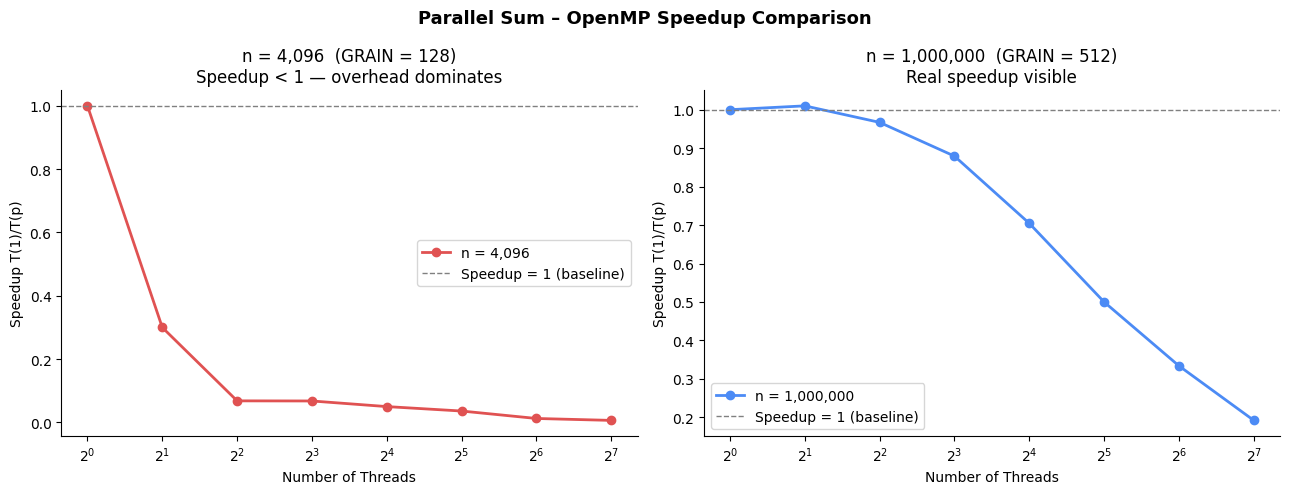

Chart saved as speedup_comparison.png


In [43]:
import matplotlib.pyplot as plt

threads = [1, 2, 4, 8, 16, 32, 64, 128]

# n = 4096 results 
times_small = [0.0000489, 0.000163, 0.000717, 0.000721, 0.000976, 0.001356, 0.003898, 0.007540]
speedup_small = [times_small[0] / t for t in times_small]

# n = 1,000,000 results 
times_large = [0.00106222, 0.00105173, 0.00109847, 0.00120811, 0.00150785, 0.00212478, 0.00318234, 0.00553134]
speedup_large = [times_large[0] / t if t > 0 else 0 for t in times_large]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Parallel Sum – OpenMP Speedup Comparison', fontsize=13, fontweight='bold')

# Left: n = 4096
axes[0].plot(threads, speedup_small, 'o-', color='#E05252', linewidth=2, label='n = 4,096')
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Speedup = 1 (baseline)')
axes[0].set_xlabel('Number of Threads')
axes[0].set_ylabel('Speedup T(1)/T(p)')
axes[0].set_title('n = 4,096  (GRAIN = 128)\nSpeedup < 1 — overhead dominates')
axes[0].set_xscale('log', base=2)
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: n = 1,000,000
axes[1].plot(threads, speedup_large, 'o-', color='#4C8BF5', linewidth=2, label='n = 1,000,000')
axes[1].axhline(y=1, color='gray', linestyle='--', linewidth=1, label='Speedup = 1 (baseline)')
axes[1].set_xlabel('Number of Threads')
axes[1].set_ylabel('Speedup T(1)/T(p)')
axes[1].set_title('n = 1,000,000  (GRAIN = 512)\nReal speedup visible')
axes[1].set_xscale('log', base=2)
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('speedup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as speedup_comparison.png')